# sep_main Phase-2 Trial Analysis
이 노트북은 `sep_main` trial 로그를 기준으로 데이터셋별 후보 런을 정리하고, trial-level Phase-2 재실행 상태와 case-eval 결과를 모아서 성능 비교와 expert weight 분리도 분석을 수행한다.

주요 목표는 다음과 같다.
- Phase-1 trial 단위에서 `괜찮았던 run`과 `separation lambda가 큰데 성능도 괜찮은 run`을 동시에 추리는 것
- 데이터셋별 8개 재학습 후보의 Phase-2 진행 상태와 seen-target 성능을 비교하는 것
- case-eval 산출물에서 expert weight separation을 수치화하고, 분리도가 높은 런을 heatmap으로 확인하는 것

In [57]:
from __future__ import annotations

import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from real_final_viz_helpers import DATASET_LABELS, PALETTE, apply_style, clean_axes

ROOT = Path.cwd()
if ROOT.name != "260419_real_final_exp":
    ROOT = Path("/workspace/FeaturedMoE/writing/260419_real_final_exp")
REPO_ROOT = ROOT.parents[1]
LOG_ROOT = REPO_ROOT / "experiments/run/artifacts/logs/real_final_ablation"
RESULT_ROOT = REPO_ROOT / "experiments/run/artifacts/results/real_final_ablation"
FIG_DIR = ROOT / "figures"
DATA_DIR = ROOT / "data"
FIG_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

PHASE1_SUMMARY = LOG_ROOT / "sep_main/summary.csv"
PHASE1_MANIFEST = LOG_ROOT / "sep_main/manifest.json"
PHASE2_SUMMARY = LOG_ROOT / "sep_main_diag_trials/summary.csv"
PHASE2_SELECTION = LOG_ROOT / "sep_main_diag_trials/sep_main_diag_trials_selection_index.csv"
PHASE2_CASE_EVAL = LOG_ROOT / "sep_main_diag_trials/sep_main_diag_trials_case_eval_index.csv"
PHASE2_CASE_EVAL_ROOT = LOG_ROOT / "sep_main_diag_trials/case_eval"
PHASE2_SCRIPT = REPO_ROOT / "experiments/run/final_experiment/separation_main_trial_phase2.py"
DATASETS = ["KuaiRecLargeStrictPosV2_0.2", "foursquare"]
METRIC_KEYS = [
    "hit@5", "hit@10", "hit@20",
    "ndcg@5", "ndcg@10", "ndcg@20",
    "mrr@5", "mrr@10", "mrr@20",
]
FAMILY_ORDER = ["memory", "focus", "tempo", "exposure"]
TIER_ORDER = ["pure", "permissive"]
STAGE_ORDER = ["macro", "mid", "micro"]


def dataset_label(name: str) -> str:
    return DATASET_LABELS.get(name, name)


def safe_float(value: object, default: float = 0.0) -> float:
    try:
        return float(value)
    except Exception:
        return float(default)


def metric_mean(metric_dict: dict | None) -> float:
    if not isinstance(metric_dict, dict):
        return 0.0
    vals = [safe_float(metric_dict.get(key), 0.0) for key in METRIC_KEYS]
    return float(sum(vals) / len(vals)) if vals else 0.0


def read_json(path: str | Path | None) -> dict:
    if not path:
        return {}
    file_path = Path(path)
    if not file_path.exists():
        return {}
    with file_path.open("r", encoding="utf-8") as handle:
        return json.load(handle)


def read_csv_if_exists(path: Path) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame()
    return pd.read_csv(path)


def normalize_metric_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for column in out.columns:
        if any(token in column for token in ["score", "mrr", "hit", "ndcg", "lambda", "rate"]):
            converted = pd.to_numeric(out[column], errors="coerce")
            if converted.notna().any():
                out[column] = converted.where(converted.notna(), out[column])
    return out


def infer_case_eval_export_dir(job_id: str) -> str:
    candidate = PHASE2_CASE_EVAL_ROOT / str(job_id)
    tables_dir = candidate / "tables"
    return str(candidate) if tables_dir.exists() else ""


def read_case_eval_table(export_dir: str | Path, table_name: str) -> pd.DataFrame:
    if not export_dir:
        return pd.DataFrame()
    path = Path(export_dir) / "tables" / table_name
    if not path.exists():
        return pd.DataFrame()
    return pd.read_csv(path)


apply_style()
print({
    "phase1_summary": PHASE1_SUMMARY.exists(),
    "phase2_selection": PHASE2_SELECTION.exists(),
    "phase2_summary": PHASE2_SUMMARY.exists(),
    "phase2_case_eval": PHASE2_CASE_EVAL.exists(),
    "phase2_case_eval_root": PHASE2_CASE_EVAL_ROOT.exists(),
})

{'phase1_summary': True, 'phase2_selection': True, 'phase2_summary': True, 'phase2_case_eval': True, 'phase2_case_eval_root': True}


## 1. 실험 로그와 체크포인트 로드
Phase-1 `sep_main` summary/result JSON과 Phase-2 selection/summary/index를 읽는다. final 결과만이 아니라 hyperopt trial 단위의 중간 test 결과도 함께 풀어서 후보 풀을 만든다.

In [58]:
phase1_summary = normalize_metric_columns(read_csv_if_exists(PHASE1_SUMMARY))
phase2_selection = normalize_metric_columns(read_csv_if_exists(PHASE2_SELECTION))
phase2_summary = normalize_metric_columns(read_csv_if_exists(PHASE2_SUMMARY))
phase2_case_eval = normalize_metric_columns(read_csv_if_exists(PHASE2_CASE_EVAL))
phase1_manifest = read_json(PHASE1_MANIFEST)
manifest_rows = {
    str(row.get("job_id", "")): row
    for row in phase1_manifest.get("rows", [])
    if str(row.get("job_id", ""))
}

trial_rows = []
for row in phase1_summary.to_dict("records"):
    result_path = row.get("result_path")
    payload = read_json(result_path)
    for trial in payload.get("trials", []):
        if str(trial.get("status", "ok")).lower() != "ok":
            continue
        params = trial.get("params", {})
        test_result = trial.get("test_result", {})
        valid_result = trial.get("valid_result", {})
        trial_rows.append(
            {
                "dataset": row.get("dataset", ""),
                "source_job_id": row.get("job_id", ""),
                "base_rank": row.get("base_rank", ""),
                "base_tag": row.get("base_tag", ""),
                "trial": int(trial.get("trial", 0) or 0),
                "learning_rate": safe_float(params.get("learning_rate")),
                "weight_decay": safe_float(params.get("weight_decay")),
                "route_consistency_lambda": safe_float(params.get("route_consistency_lambda")),
                "route_separation_lambda": safe_float(params.get("route_separation_lambda")),
                "valid_mrr20": safe_float(valid_result.get("mrr@20")),
                "test_mrr20": safe_float(test_result.get("mrr@20")),
                "valid_hr10": safe_float(valid_result.get("hit@10")),
                "test_hr10": safe_float(test_result.get("hit@10")),
                "valid_mean": metric_mean(valid_result),
                "test_mean": metric_mean(test_result),
                "phase1_result_path": result_path,
                "phase1_status": row.get("status", ""),
            }
        )
trial_pool = pd.DataFrame(trial_rows)
trial_pool["dataset_label"] = trial_pool["dataset"].map(dataset_label)

print("phase1 runs", len(phase1_summary))
print("trial pool", len(trial_pool))
phase1_summary[["dataset", "job_id", "status", "test_score", "test_mrr20", "result_path"]]

phase1 runs 8
trial pool 210


,dataset,job_id,status,test_score,test_mrr20,result_path
0,KuaiRecLargeStrictPosV2_0.2,SEP_MAIN_KUAIRECLARGESTRICTPOSV2_0_2_SEPARATIO...,fail,0.000000,0.0000,/workspace/FeaturedMoE/experiments/run/artifac...
1,foursquare,SEP_MAIN_FOURSQUARE_SEPARATION_MAIN_R01_S1,ok,0.229267,0.1715,/workspace/FeaturedMoE/experiments/run/artifac...
2,foursquare,SEP_MAIN_FOURSQUARE_SEPARATION_MAIN_R91_S1,ok,0.229013,0.1743,/workspace/FeaturedMoE/experiments/run/artifac...
3,foursquare,SEP_MAIN_FOURSQUARE_SEPARATION_MAIN_R02_S1,ok,0.225189,0.1678,/workspace/FeaturedMoE/experiments/run/artifac...
4,foursquare,SEP_MAIN_FOURSQUARE_SEPARATION_MAIN_R92_S1,ok,0.231799,0.1758,/workspace/FeaturedMoE/experiments/run/artifac...
5,KuaiRecLargeStrictPosV2_0.2,SEP_MAIN_KUAIRECLARGESTRICTPOSV2_0_2_SEPARATIO...,ok,0.342781,0.3359,/workspace/FeaturedMoE/experiments/run/artifac...
6,KuaiRecLargeStrictPosV2_0.2,SEP_MAIN_KUAIRECLARGESTRICTPOSV2_0_2_SEPARATIO...,ok,0.346081,0.3381,/workspace/FeaturedMoE/experiments/run/artifac...
7,KuaiRecLargeStrictPosV2_0.2,SEP_MAIN_KUAIRECLARGESTRICTPOSV2_0_2_SEPARATIO...,ok,0.345268,0.3366,/workspace/FeaturedMoE/experiments/run/artifac...


## 2. 런 메타데이터 정규화 및 데이터셋별 집계
Phase-1 trial 풀과 현재 Phase-2 selection/summary를 표준 컬럼으로 정리한다. dataset, phase 상태, lambda, checkpoint, case-eval 가능 여부를 한 테이블에서 비교할 수 있게 합친다.

In [59]:
phase2_table = phase2_selection.copy()
if not phase2_summary.empty:
    phase2_table = phase2_table.merge(
        phase2_summary[["job_id", "status", "test_score", "test_mrr20", "checkpoint_file", "result_path"]].rename(
            columns={
                "job_id": "diag_job_id",
                "status": "diag_status_live",
                "test_score": "diag_test_score_live",
                "test_mrr20": "diag_test_mrr20_live",
                "checkpoint_file": "diag_checkpoint_file_live",
                "result_path": "diag_result_path_live",
            }
        ),
        on="diag_job_id",
        how="left",
    )
if not phase2_case_eval.empty:
    merge_cols = [col for col in ["result_path", "case_eval_export_dir"] if col in phase2_case_eval.columns]
    if merge_cols:
        phase2_table = phase2_table.merge(
            phase2_case_eval[merge_cols].rename(columns={"result_path": "diag_result_path_live"}),
            on="diag_result_path_live",
            how="left",
        )

for column in ["diag_status", "diag_status_live"]:
    if column not in phase2_table.columns:
        phase2_table[column] = ""
phase2_table["diag_status_final"] = phase2_table["diag_status_live"].fillna(phase2_table["diag_status"]).replace("", np.nan).fillna("pending")

if "case_eval_export_dir" not in phase2_table.columns:
    phase2_table["case_eval_export_dir"] = ""
phase2_table["case_eval_export_dir"] = phase2_table["case_eval_export_dir"].fillna("")
phase2_table["case_eval_export_dir_inferred"] = [infer_case_eval_export_dir(job_id) for job_id in phase2_table.get("diag_job_id", [])]
phase2_table["case_eval_export_dir"] = phase2_table["case_eval_export_dir"].where(
    phase2_table["case_eval_export_dir"].astype(str).str.len().gt(0),
    phase2_table["case_eval_export_dir_inferred"],
)
phase2_table["case_eval_ready"] = phase2_table["case_eval_export_dir"].astype(str).str.len().gt(0)
phase2_table["case_eval_performance_ready"] = [
    (Path(path) / "tables" / "case_eval_performance.csv").exists() if path else False
    for path in phase2_table["case_eval_export_dir"]
 ]
phase2_table["case_eval_expert_ready"] = [
    (Path(path) / "tables" / "case_eval_expert_profile.csv").exists() if path else False
    for path in phase2_table["case_eval_export_dir"]
]
phase2_table["dataset_label"] = phase2_table["dataset"].map(dataset_label)

summary_cols = [
    "dataset_label", "selection_bucket", "selection_rank", "source_trial",
    "source_test_mean", "source_test_mrr20", "route_separation_lambda",
    "diag_status_final", "diag_test_score_live", "diag_test_mrr20_live",
    "case_eval_ready", "case_eval_performance_ready", "case_eval_expert_ready",
]
phase2_table[summary_cols].sort_values(["dataset_label", "selection_bucket", "selection_rank"])

,dataset_label,selection_bucket,selection_rank,source_trial,source_test_mean,source_test_mrr20,route_separation_lambda,diag_status_final,diag_test_score_live,diag_test_mrr20_live,case_eval_ready,case_eval_performance_ready,case_eval_expert_ready
24,Foursquare,highsep,1,23,0.230889,0.1751,0.028825,ok,0.230904,0.1751,True,True,True
25,Foursquare,highsep,1,23,0.230889,0.1751,0.028825,ok,0.230904,0.1751,True,True,True
26,Foursquare,highsep,2,12,0.229700,0.1733,0.028821,ok,0.229700,0.1733,True,True,True
27,Foursquare,highsep,2,12,0.229700,0.1733,0.028821,ok,0.229700,0.1733,True,True,True
28,Foursquare,highsep,3,16,0.230122,0.1720,0.027538,ok,0.230138,0.1720,True,True,True
29,Foursquare,highsep,3,16,0.230122,0.1720,0.027538,ok,0.230135,0.1720,True,True,True
30,Foursquare,highsep,4,29,0.230133,0.1731,0.026363,ok,0.230133,0.1731,True,True,True
31,Foursquare,highsep,4,29,0.230133,0.1731,0.026363,ok,0.230112,0.1730,True,True,True
16,Foursquare,perf,1,3,0.231856,0.1755,0.001493,ok,0.231867,0.1755,True,True,True
17,Foursquare,perf,1,3,0.231856,0.1755,0.001493,ok,0.231906,0.1756,True,True,True


## 3. 중간 테스트 성능 포함 후보 런 스코어링
Phase-1 trial 단위의 test 성능, validation-test gap 기반 안정성, separation lambda, Phase-2 미실행 여부를 함께 사용해 후보 점수를 계산한다.

In [60]:
scored_pool = trial_pool.copy()
scored_pool["stability"] = 1.0 - (scored_pool["valid_mean"] - scored_pool["test_mean"]).abs().clip(upper=0.05) / 0.05
scored_pool["pending_phase2"] = 1.0
if not phase2_selection.empty:
    existing = set(zip(phase2_selection["source_job_id"], phase2_selection["source_trial"]))
    scored_pool["pending_phase2"] = [0.0 if (job, trial) in existing else 1.0 for job, trial in zip(scored_pool["source_job_id"], scored_pool["trial"])]

for column in ["test_mean", "test_mrr20", "route_separation_lambda", "stability"]:
    lo = scored_pool[column].min()
    hi = scored_pool[column].max()
    scored_pool[f"norm_{column}"] = 0.0 if hi <= lo else (scored_pool[column] - lo) / (hi - lo)

scored_pool["candidate_score"] = (
    0.42 * scored_pool["norm_test_mean"]
    + 0.24 * scored_pool["norm_test_mrr20"]
    + 0.18 * scored_pool["norm_route_separation_lambda"]
    + 0.10 * scored_pool["norm_stability"]
    + 0.06 * scored_pool["pending_phase2"]
)
scored_pool["dataset_label"] = scored_pool["dataset"].map(dataset_label)

scored_pool.sort_values(["dataset", "candidate_score"], ascending=[True, False]).groupby("dataset_label").head(10)[[
    "dataset_label", "source_job_id", "trial", "test_mean", "test_mrr20", "route_separation_lambda", "stability", "candidate_score"
]]

,dataset_label,source_job_id,trial,test_mean,test_mrr20,route_separation_lambda,stability,candidate_score
203,KuaiRec,SEP_MAIN_KUAIRECLARGESTRICTPOSV2_0_2_SEPARATIO...,24,0.345189,0.3364,0.029398,0.000000,0.872954
201,KuaiRec,SEP_MAIN_KUAIRECLARGESTRICTPOSV2_0_2_SEPARATIO...,22,0.345267,0.3366,0.028998,0.000000,0.870955
202,KuaiRec,SEP_MAIN_KUAIRECLARGESTRICTPOSV2_0_2_SEPARATIO...,23,0.343900,0.3379,0.029314,0.000000,0.870315
126,KuaiRec,SEP_MAIN_KUAIRECLARGESTRICTPOSV2_0_2_SEPARATIO...,7,0.343533,0.3354,0.029530,0.000000,0.867134
187,KuaiRec,SEP_MAIN_KUAIRECLARGESTRICTPOSV2_0_2_SEPARATIO...,8,0.344611,0.3365,0.025669,0.000000,0.847743
185,KuaiRec,SEP_MAIN_KUAIRECLARGESTRICTPOSV2_0_2_SEPARATIO...,6,0.339311,0.3285,0.029540,0.000000,0.844384
195,KuaiRec,SEP_MAIN_KUAIRECLARGESTRICTPOSV2_0_2_SEPARATIO...,16,0.342156,0.3317,0.026700,0.000000,0.839911
176,KuaiRec,SEP_MAIN_KUAIRECLARGESTRICTPOSV2_0_2_SEPARATIO...,27,0.348922,0.3404,0.020252,0.000000,0.832677
175,KuaiRec,SEP_MAIN_KUAIRECLARGESTRICTPOSV2_0_2_SEPARATIO...,26,0.348033,0.3396,0.029777,0.000000,0.828765
173,KuaiRec,SEP_MAIN_KUAIRECLARGESTRICTPOSV2_0_2_SEPARATIO...,24,0.346756,0.3382,0.020023,0.000000,0.821324


## 4. Phase 2 재실행 대상 8개 런 선택
데이터셋별로 8개를 고른다. `overall 우수` 4개와 `high separation` 4개를 quota로 유지하되, 이미 선택된 trial은 중복 선택하지 않는다.

In [61]:
def select_phase2_candidates(pool: pd.DataFrame, per_dataset: int = 8, perf_slots: int = 4, sep_min: float = 1e-2) -> pd.DataFrame:
    chosen = []
    for dataset, sub in pool.groupby("dataset", sort=False):
        used = set()
        perf = sub.sort_values(["test_mean", "test_mrr20", "candidate_score"], ascending=False)
        perf_pick = []
        for row in perf.itertuples(index=False):
            key = (row.source_job_id, int(row.trial))
            if key in used:
                continue
            used.add(key)
            perf_pick.append(row._asdict())
            if len(perf_pick) >= perf_slots:
                break

        best_mean = perf["test_mean"].max() if not perf.empty else 0.0
        ratio = 0.985
        high_sep = pd.DataFrame()
        while ratio >= 0.95:
            high_sep = sub[(sub["route_separation_lambda"] >= sep_min) & (sub["test_mean"] >= best_mean * ratio)]
            if len(high_sep) >= per_dataset - perf_slots:
                break
            ratio -= 0.01
        if high_sep.empty:
            high_sep = sub[sub["route_separation_lambda"] >= sep_min]
        if high_sep.empty:
            high_sep = sub.copy()
        high_sep = high_sep.sort_values(["route_separation_lambda", "test_mean", "test_mrr20"], ascending=False)
        high_sep_pick = []
        for row in high_sep.itertuples(index=False):
            key = (row.source_job_id, int(row.trial))
            if key in used:
                continue
            used.add(key)
            high_sep_pick.append(row._asdict())
            if len(high_sep_pick) >= per_dataset - perf_slots:
                break

        for rank, item in enumerate(perf_pick, start=1):
            item["selection_bucket"] = "perf"
            item["selection_rank"] = rank
            chosen.append(item)
        for rank, item in enumerate(high_sep_pick, start=1):
            item["selection_bucket"] = "highsep"
            item["selection_rank"] = rank
            chosen.append(item)
    return pd.DataFrame(chosen)

selected_from_notebook = select_phase2_candidates(scored_pool)
selected_from_notebook["dataset_label"] = selected_from_notebook["dataset"].map(dataset_label)
selected_from_notebook.sort_values(["dataset", "selection_bucket", "selection_rank"])[[
    "dataset_label", "selection_bucket", "selection_rank", "trial", "test_mean", "test_mrr20", "route_separation_lambda", "candidate_score"
]]

,dataset_label,selection_bucket,selection_rank,trial,test_mean,test_mrr20,route_separation_lambda,candidate_score
12,KuaiRec,highsep,1,26,0.348033,0.3396,0.029777,0.828765
13,KuaiRec,highsep,2,15,0.347689,0.3382,0.027396,0.810776
14,KuaiRec,highsep,3,13,0.346100,0.3380,0.026876,0.802135
15,KuaiRec,highsep,4,10,0.345878,0.3369,0.020756,0.761385
8,KuaiRec,perf,1,3,0.350867,0.3412,0.004595,0.681329
9,KuaiRec,perf,2,25,0.350556,0.3410,0.001655,0.661536
10,KuaiRec,perf,3,4,0.350467,0.3408,0.017816,0.762812
11,KuaiRec,perf,4,7,0.350078,0.3407,0.009100,0.706512
4,Foursquare,highsep,1,23,0.230889,0.1751,0.028825,0.304349
5,Foursquare,highsep,2,12,0.229700,0.1733,0.028821,0.306846


## 5. Phase 2 실행 스크립트 생성
trial-level Phase-2 runner를 호출하는 명령과 재현용 shell script를 만든다. 현재 선택 결과가 이미 있으면 그 결과를 기준으로, 없으면 notebook 내부 선택 결과를 기준으로 명령을 기록한다.

In [62]:
active_selection = phase2_selection.copy() if not phase2_selection.empty else selected_from_notebook.copy()
run_command = (
    "cd /workspace/FeaturedMoE && "
    "/venv/FMoE/bin/python experiments/run/final_experiment/separation_main_trial_phase2.py "
    "--datasets KuaiRecLargeStrictPosV2_0.2,foursquare --gpus 0,1,2,3,4,5,6,7 --resume"
)
command_script = DATA_DIR / "sep_main_phase2_trial_commands.sh"
script_lines = [
    "#!/usr/bin/env bash",
    "set -euo pipefail",
    run_command,
    "",
    "# Selected trial candidates",
]
for row in active_selection.sort_values(["dataset", "selection_bucket", "selection_rank"]).to_dict("records"):
    script_lines.append(
        f"# {row.get('dataset')} {row.get('selection_bucket')}#{int(row.get('selection_rank', 0))} "
        f"trial={int(row.get('source_trial', row.get('trial', 0)))} sep={safe_float(row.get('route_separation_lambda')):.4g} "
        f"test_mrr20={safe_float(row.get('source_test_mrr20', row.get('test_mrr20'))):.4f}"
    )
command_script.write_text("\n".join(script_lines) + "\n", encoding="utf-8")
print(run_command)
print(command_script)

cd /workspace/FeaturedMoE && /venv/FMoE/bin/python experiments/run/final_experiment/separation_main_trial_phase2.py --datasets KuaiRecLargeStrictPosV2_0.2,foursquare --gpus 0,1,2,3,4,5,6,7 --resume
/workspace/FeaturedMoE/writing/260419_real_final_exp/data/sep_main_phase2_trial_commands.sh


## 6. 학습 상태 모니터링 및 결과 수집
선택된 Phase-2 후보가 실제로 `pending`, `ok`, `fail` 중 어디에 있는지 집계하고, 완료된 런의 seen-target 결과를 다시 합친다.

In [63]:
monitor_table = phase2_table.copy()
if monitor_table.empty and not active_selection.empty:
    monitor_table = active_selection.copy()
    monitor_table["diag_status_final"] = "pending"
monitor_table["dataset_label"] = monitor_table["dataset"].map(dataset_label)
status_counts = (
    monitor_table.groupby(["dataset_label", "diag_status_final"], dropna=False)
    .size()
    .rename("count")
    .reset_index()
    .sort_values(["dataset_label", "diag_status_final"])
)
status_counts

,dataset_label,diag_status_final,count
0,Foursquare,ok,16
1,KuaiRec,ok,16


## 7. 선택 런 전체에 대한 Case-Eval 실행
Phase-2 runner가 case-eval까지 처리하도록 만들어져 있으므로, 여기서는 case-eval 준비 상태와 export 경로를 확인한다. 필요하면 동일 runner를 다시 호출해 누락분을 채울 수 있다.

In [64]:
case_eval_status = monitor_table[[
    "dataset_label", "selection_bucket", "selection_rank", "diag_status_final",
    "case_eval_ready", "case_eval_performance_ready", "case_eval_expert_ready", "case_eval_export_dir",
]].copy()
case_eval_status = case_eval_status.sort_values(["dataset_label", "selection_bucket", "selection_rank"])

case_eval_progress = (
    case_eval_status.groupby("dataset_label", dropna=False)[["case_eval_ready", "case_eval_performance_ready", "case_eval_expert_ready"]]
    .sum()
    .reset_index()
    .rename(
        columns={
            "case_eval_ready": "runs_with_export_dir",
            "case_eval_performance_ready": "runs_with_performance_table",
            "case_eval_expert_ready": "runs_with_expert_table",
        }
    )
)

display(case_eval_progress)
case_eval_status

,dataset_label,runs_with_export_dir,runs_with_performance_table,runs_with_expert_table
0,Foursquare,16,16,16
1,KuaiRec,16,16,16


,dataset_label,selection_bucket,selection_rank,diag_status_final,case_eval_ready,case_eval_performance_ready,case_eval_expert_ready,case_eval_export_dir
24,Foursquare,highsep,1,ok,True,True,True,/workspace/FeaturedMoE/experiments/run/artifac...
25,Foursquare,highsep,1,ok,True,True,True,/workspace/FeaturedMoE/experiments/run/artifac...
26,Foursquare,highsep,2,ok,True,True,True,/workspace/FeaturedMoE/experiments/run/artifac...
27,Foursquare,highsep,2,ok,True,True,True,/workspace/FeaturedMoE/experiments/run/artifac...
28,Foursquare,highsep,3,ok,True,True,True,/workspace/FeaturedMoE/experiments/run/artifac...
29,Foursquare,highsep,3,ok,True,True,True,/workspace/FeaturedMoE/experiments/run/artifac...
30,Foursquare,highsep,4,ok,True,True,True,/workspace/FeaturedMoE/experiments/run/artifac...
31,Foursquare,highsep,4,ok,True,True,True,/workspace/FeaturedMoE/experiments/run/artifac...
16,Foursquare,perf,1,ok,True,True,True,/workspace/FeaturedMoE/experiments/run/artifac...
17,Foursquare,perf,1,ok,True,True,True,/workspace/FeaturedMoE/experiments/run/artifac...


## 8. Clean Figure Set
이제부터는 figure-first로 정리한다. 위쪽 셀은 로그 로드와 상태 확인까지만 유지하고, 아래쪽은 다음 여섯 가지 그림만 만든다.

1. Phase-1 trial cloud: separation lambda vs test score
2. Phase-1 trial cloud: separation lambda vs consistency lambda, 성능을 size/alpha로 표현
3. Completed diag run cloud: separation lambda vs consistency lambda, pure macro specialization을 size/color로 표현
4. Pure case heatmap: macro group 4개 weight 평균 (pre top-k)
5. Pure case heatmap: macro expert weight 평균 (pre top-k)
6. Extreme pure subset heatmap: 5와 같지만 가장 극단적인 pure case만 추림

In [65]:
PHASE1_FLOOR_RATIO = 0.60
PURE_STAGE = "macro"
PURE_CASE_RUNS = {
    "KuaiRecLargeStrictPosV2_0.2": "SEP_MAIN_KUAIRECLARGESTRICTPOSV2_0_2_SEPARATION_MAIN_R01_S1_PERF02_T25_DIAG",
    "foursquare": "SEP_MAIN_FOURSQUARE_SEPARATION_MAIN_R92_S1_PERF01_T03_DIAG",
}


def stage_bucket_from_values(*values: object) -> str | None:
    for value in values:
        text = str(value).strip().lower()
        if text.startswith("macro"):
            return "macro"
        if text.startswith("mid"):
            return "mid"
        if text.startswith("micro"):
            return "micro"
    return None



def family_title(value: str) -> str:
    text = str(value)
    return text[:1].upper() + text[1:] if text else text



def label_sort_key(label: str) -> tuple[int, int, str]:
    text = str(label)
    if text.endswith("_union"):
        return (-1, -1, text)
    core = text.split("__", 1)[-1]
    family = core
    polarity = ""
    if "_" in core:
        family, polarity = core.rsplit("_", 1)
    family_rank = FAMILY_ORDER.index(family) if family in FAMILY_ORDER else len(FAMILY_ORDER)
    polarity_rank = {"minus": 0, "plus": 1}.get(polarity, 2)
    return (family_rank, polarity_rank, text)



def prefer_eval_split(df: pd.DataFrame, preferred: str = "test") -> pd.DataFrame:
    if df.empty or "eval_split" not in df.columns:
        return df.copy()
    preferred_df = df[df["eval_split"].astype(str).str.lower() == preferred].copy()
    if not preferred_df.empty:
        return preferred_df
    fallback_df = df[df["eval_split"].astype(str).str.lower() == "valid"].copy()
    return fallback_df if not fallback_df.empty else df.copy()



def resolve_export_dir(diag_job_id: str) -> Path:
    matched = phase2_table.loc[phase2_table["diag_job_id"] == diag_job_id, "case_eval_export_dir"].dropna().astype(str)
    if not matched.empty:
        candidate = Path(matched.iloc[0])
        if (candidate / "tables").exists():
            return candidate
    inferred = PHASE2_CASE_EVAL_ROOT / diag_job_id
    if (inferred / "tables").exists():
        return inferred
    raise FileNotFoundError(f"Missing case-eval export for {diag_job_id}")



def load_case_eval_bundle(diag_job_id: str) -> dict[str, object]:
    export_dir = resolve_export_dir(diag_job_id)
    bundle = {
        "diag_job_id": diag_job_id,
        "export_dir": export_dir,
        "stage": read_case_eval_table(export_dir, "case_eval_stage_summary.csv"),
        "routing": read_case_eval_table(export_dir, "case_eval_routing_profile.csv"),
        "expert": read_case_eval_table(export_dir, "case_eval_expert_profile.csv"),
        "family_heat": read_case_eval_table(export_dir, "case_eval_family_expert_heatmap.csv"),
        "router_scalars": read_case_eval_table(export_dir, "case_eval_router_diag_scalars.csv"),
    }
    for key in ["stage", "routing", "expert", "family_heat"]:
        table = bundle[key]
        if table.empty:
            continue
        fallback = table["stage_key"] if "stage_key" in table.columns else ""
        stage_name = table["stage_name"] if "stage_name" in table.columns else ""
        table["stage_bucket"] = [stage_bucket_from_values(name, fb) for name, fb in zip(stage_name, fallback)]
        bundle[key] = table
    return bundle



def pure_case_order(stage_df: pd.DataFrame) -> list[str]:
    pure = stage_df[stage_df.get("tier", "").astype(str) == "pure"].copy()
    labels = pure.get("label", pd.Series(dtype=str)).dropna().astype(str).unique().tolist()
    return sorted(labels, key=label_sort_key)



def build_pure_family_matrix(bundle: dict[str, object]) -> pd.DataFrame:
    routing = bundle["routing"].copy()
    routing = routing[
        routing.get("tier", "").astype(str).eq("pure")
        & routing.get("stage_bucket", "").astype(str).eq(PURE_STAGE)
    ].copy()
    routing = prefer_eval_split(routing, preferred="test")
    if routing.empty:
        return pd.DataFrame()
    matrix = (
        routing.groupby(["label", "routed_family"], as_index=False)["usage_share"]
        .mean()
        .pivot(index="label", columns="routed_family", values="usage_share")
        .fillna(0.0)
    )
    row_order = [label for label in pure_case_order(bundle["stage"]) if label in matrix.index]
    col_order = [family for family in FAMILY_ORDER if family in matrix.columns]
    return matrix.reindex(index=row_order, columns=col_order).fillna(0.0)



def build_pure_expert_matrix(bundle: dict[str, object], labels: list[str] | None = None) -> pd.DataFrame:
    heat = bundle["family_heat"].copy()
    heat = heat[
        heat.get("tier", "").astype(str).eq("pure")
        & heat.get("stage_bucket", "").astype(str).eq(PURE_STAGE)
    ].copy()
    heat = prefer_eval_split(heat, preferred="test")
    if labels is not None:
        heat = heat[heat["label"].astype(str).isin(labels)].copy()
    if heat.empty:
        return pd.DataFrame()
    expert_order = (
        heat[["expert_name", "source_family", "expert_index"]]
        .drop_duplicates()
        .sort_values(["source_family", "expert_index", "expert_name"])
    )
    matrix = (
        heat.groupby(["label", "expert_name"], as_index=False)["family_share"]
        .mean()
        .pivot(index="label", columns="expert_name", values="family_share")
        .fillna(0.0)
    )
    row_order = [label for label in pure_case_order(bundle["stage"]) if label in matrix.index]
    if labels is not None:
        row_order = [label for label in labels if label in matrix.index]
    col_order = [name for name in expert_order["expert_name"].tolist() if name in matrix.columns]
    return matrix.reindex(index=row_order, columns=col_order).fillna(0.0)



def select_extreme_pure_labels(bundle: dict[str, object], top_n: int = 4) -> list[str]:
    stage = bundle["stage"].copy()
    stage = stage[
        stage.get("tier", "").astype(str).eq("pure")
        & stage.get("scope", "").astype(str).eq("tier_group")
        & stage.get("stage_bucket", "").astype(str).eq(PURE_STAGE)
    ].copy()
    stage = prefer_eval_split(stage, preferred="test")
    if stage.empty:
        return []
    ranked = stage.sort_values(
        ["group_top1_max_frac", "feature_group_consistency_mean_score", "group_n_eff"],
        ascending=[False, False, True],
    )
    chosen = ranked["label"].dropna().astype(str).drop_duplicates().head(top_n).tolist()
    if "pure_union" in pure_case_order(bundle["stage"]):
        return ["pure_union"] + [label for label in chosen if label != "pure_union"]
    return chosen



def summarize_specialization(bundle: dict[str, object]) -> dict[str, float]:
    stage = bundle["stage"].copy()
    stage = stage[
        stage.get("tier", "").astype(str).eq("pure")
        & stage.get("scope", "").astype(str).eq("tier_group")
        & stage.get("stage_bucket", "").astype(str).eq(PURE_STAGE)
    ].copy()
    stage = prefer_eval_split(stage, preferred="test")
    if stage.empty:
        return {}
    top1 = pd.to_numeric(stage["group_top1_max_frac"], errors="coerce").mean()
    entropy = pd.to_numeric(stage["group_entropy_mean"], errors="coerce").mean()
    consistency = pd.to_numeric(stage["feature_group_consistency_mean_score"], errors="coerce").mean()
    entropy_norm = np.clip(entropy / np.log(len(FAMILY_ORDER)), 0.0, 1.0)
    score = 0.5 * top1 + 0.5 * (1.0 - entropy_norm)
    return {
        "pure_macro_top1": float(top1),
        "pure_macro_group_entropy": float(entropy),
        "pure_macro_consistency": float(consistency),
        "pure_macro_specialization": float(score),
    }


phase1_plot_pool = trial_pool[trial_pool["dataset"].isin(DATASETS)].copy()
phase1_filter_rows = []
kept_frames = []
for dataset, sub in phase1_plot_pool.groupby("dataset", sort=False):
    positive = sub.loc[sub["test_mean"] > 0, "test_mean"]
    if positive.empty:
        threshold = 0.0
    else:
        threshold = max(float(positive.quantile(0.05)), float(positive.max() * PHASE1_FLOOR_RATIO))
    tagged = sub.copy()
    tagged["collapse_threshold"] = threshold
    tagged["is_catastrophic"] = tagged["test_mean"] < threshold
    kept_frames.append(tagged[~tagged["is_catastrophic"]].copy())
    phase1_filter_rows.append(
        {
            "dataset": dataset_label(dataset),
            "phase1_trials_total": len(tagged),
            "kept_for_plots": int((~tagged["is_catastrophic"]).sum()),
            "dropped_as_collapsed": int(tagged["is_catastrophic"].sum()),
            "collapse_threshold": threshold,
        }
    )
phase1_plot_pool = pd.concat(kept_frames, ignore_index=True)
phase1_filter_summary = pd.DataFrame(phase1_filter_rows)
phase1_plot_pool["dataset_label"] = phase1_plot_pool["dataset"].map(dataset_label)

selected_case_bundles = {dataset: load_case_eval_bundle(job_id) for dataset, job_id in PURE_CASE_RUNS.items()}

specialization_rows = []
for row in phase2_table.to_dict("records"):
    if str(row.get("diag_status_final", "")).lower() != "ok":
        continue
    diag_job_id = str(row.get("diag_job_id", ""))
    if not diag_job_id:
        continue
    try:
        bundle = load_case_eval_bundle(diag_job_id)
    except Exception:
        continue
    metrics = summarize_specialization(bundle)
    if not metrics:
        continue
    specialization_rows.append(
        {
            "dataset": row.get("dataset", ""),
            "dataset_label": dataset_label(row.get("dataset", "")),
            "selection_bucket": row.get("selection_bucket", ""),
            "selection_rank": int(safe_float(row.get("selection_rank"), 0)),
            "diag_job_id": diag_job_id,
            "run_label": f"{row.get('selection_bucket')}#{int(safe_float(row.get('selection_rank'), 0))}",
            "route_separation_lambda": safe_float(row.get("route_separation_lambda")),
            "route_consistency_lambda": safe_float(row.get("route_consistency_lambda")),
            "diag_test_score": safe_float(row.get("diag_test_score_live")),
            "diag_test_mrr20": safe_float(row.get("diag_test_mrr20_live")),
            **metrics,
        }
    )
diag_specialization = pd.DataFrame(specialization_rows)

selected_case_rows = []
for dataset, diag_job_id in PURE_CASE_RUNS.items():
    row = phase2_table.loc[phase2_table["diag_job_id"] == diag_job_id].iloc[0]
    metrics = diag_specialization.loc[diag_specialization["diag_job_id"] == diag_job_id]
    metric_row = metrics.iloc[0].to_dict() if not metrics.empty else {}
    selected_case_rows.append(
        {
            "dataset": dataset_label(dataset),
            "diag_job_id": diag_job_id,
            "selection_bucket": row.get("selection_bucket"),
            "selection_rank": int(safe_float(row.get("selection_rank"), 0)),
            "source_trial": int(safe_float(row.get("source_trial"), 0)),
            "route_consistency_lambda": safe_float(row.get("route_consistency_lambda")),
            "route_separation_lambda": safe_float(row.get("route_separation_lambda")),
            "diag_test_score": safe_float(row.get("diag_test_score_live")),
            "pure_macro_specialization": safe_float(metric_row.get("pure_macro_specialization"), np.nan),
            "pure_case_count": len(pure_case_order(selected_case_bundles[dataset]["stage"])),
        }
    )
selected_case_runs = pd.DataFrame(selected_case_rows)

print("specialization score = 0.5 * pure macro top-1 max frac + 0.5 * (1 - group entropy / log(4))")
display(phase1_filter_summary.style.format({"collapse_threshold": "{:.4f}"}))
display(selected_case_runs.style.format({
    "route_consistency_lambda": "{:.3e}",
    "route_separation_lambda": "{:.3e}",
    "diag_test_score": "{:.4f}",
    "pure_macro_specialization": "{:.3f}",
}))

specialization score = 0.5 * pure macro top-1 max frac + 0.5 * (1 - group entropy / log(4))


,dataset,phase1_trials_total,kept_for_plots,dropped_as_collapsed,collapse_threshold
0,Foursquare,120,114,6,0.2220
1,KuaiRec,90,85,5,0.3325


,dataset,diag_job_id,selection_bucket,selection_rank,source_trial,route_consistency_lambda,route_separation_lambda,diag_test_score,pure_macro_specialization,pure_case_count
0,KuaiRec,SEP_MAIN_KUAIRECLARGESTRICTPOSV2_0_2_SEPARATION_MAIN_R01_S1_PERF02_T25_DIAG,perf,2,25,6.547e-04,1.655e-03,0.3506,0.183,9
1,Foursquare,SEP_MAIN_FOURSQUARE_SEPARATION_MAIN_R92_S1_PERF01_T03_DIAG,perf,1,3,2.177e-04,1.493e-03,0.2319,0.232,9


## 9. Phase-1 Trial Clouds
Phase-1은 trial 단위로 최대한 넓게 쓰되, 데이터셋별 catastrophic outlier만 제외한다. lambda 축은 범위가 넓어서 log scale로 본다.

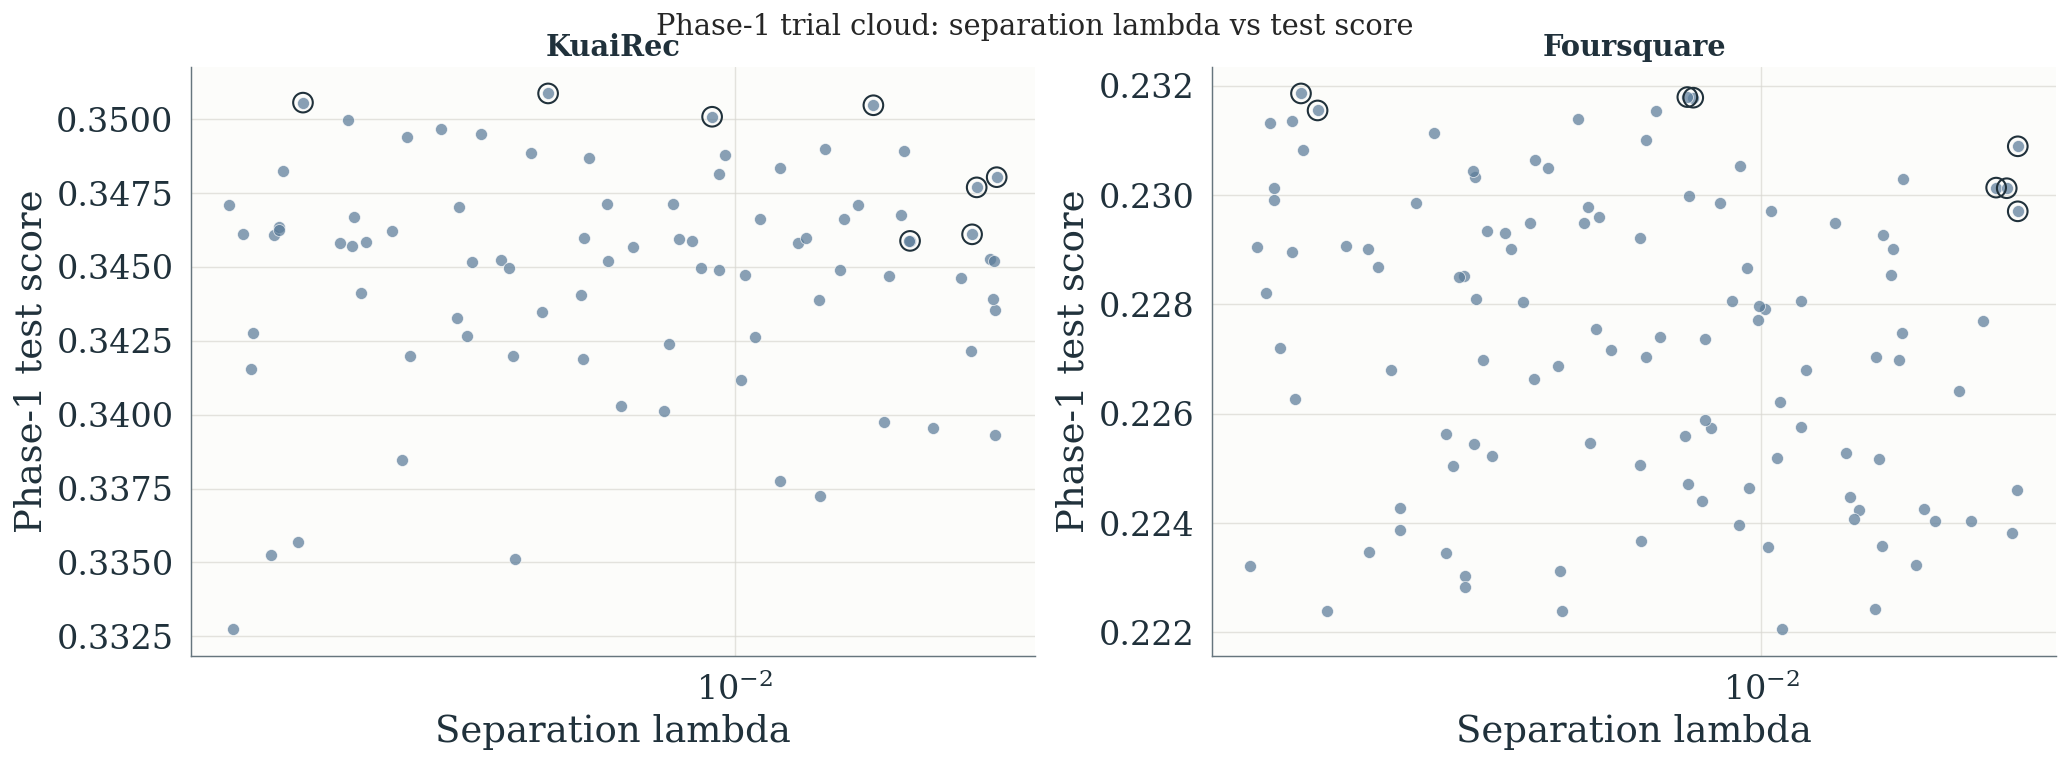

In [66]:
phase1_overlay = phase2_selection[phase2_selection["dataset"].isin(DATASETS)].copy()
phase1_overlay["dataset_label"] = phase1_overlay["dataset"].map(dataset_label)
phase1_overlay["run_label"] = [
    f"{bucket}#{int(rank)}" for bucket, rank in zip(phase1_overlay["selection_bucket"], phase1_overlay["selection_rank"])
]

apply_style()
fig, axes = plt.subplots(1, len(DATASETS), figsize=(15.8, 5.6), constrained_layout=True)
if len(DATASETS) == 1:
    axes = [axes]

for ax, dataset in zip(axes, DATASETS):
    sub = phase1_plot_pool[phase1_plot_pool["dataset"] == dataset].copy()
    overlay = phase1_overlay[phase1_overlay["dataset"] == dataset].copy()
    ax.scatter(
        sub["route_separation_lambda"].clip(lower=1e-7),
        sub["test_mean"],
        s=44,
        color=PALETTE["blue"],
        alpha=0.72,
        edgecolor="white",
        linewidth=0.45,
    )
    if not overlay.empty:
        ax.scatter(
            overlay["route_separation_lambda"].clip(lower=1e-7),
            overlay["source_test_mean"],
            s=118,
            facecolor="none",
            edgecolor=PALETTE["ink"],
            linewidth=1.15,
        )
    ax.set_xscale("log")
    ax.set_title(dataset_label(dataset))
    ax.set_xlabel("Separation lambda")
    ax.set_ylabel("Phase-1 test score")
    clean_axes(ax)

fig.suptitle("Phase-1 trial cloud: separation lambda vs test score", y=1.02, fontsize=16)
plt.show()

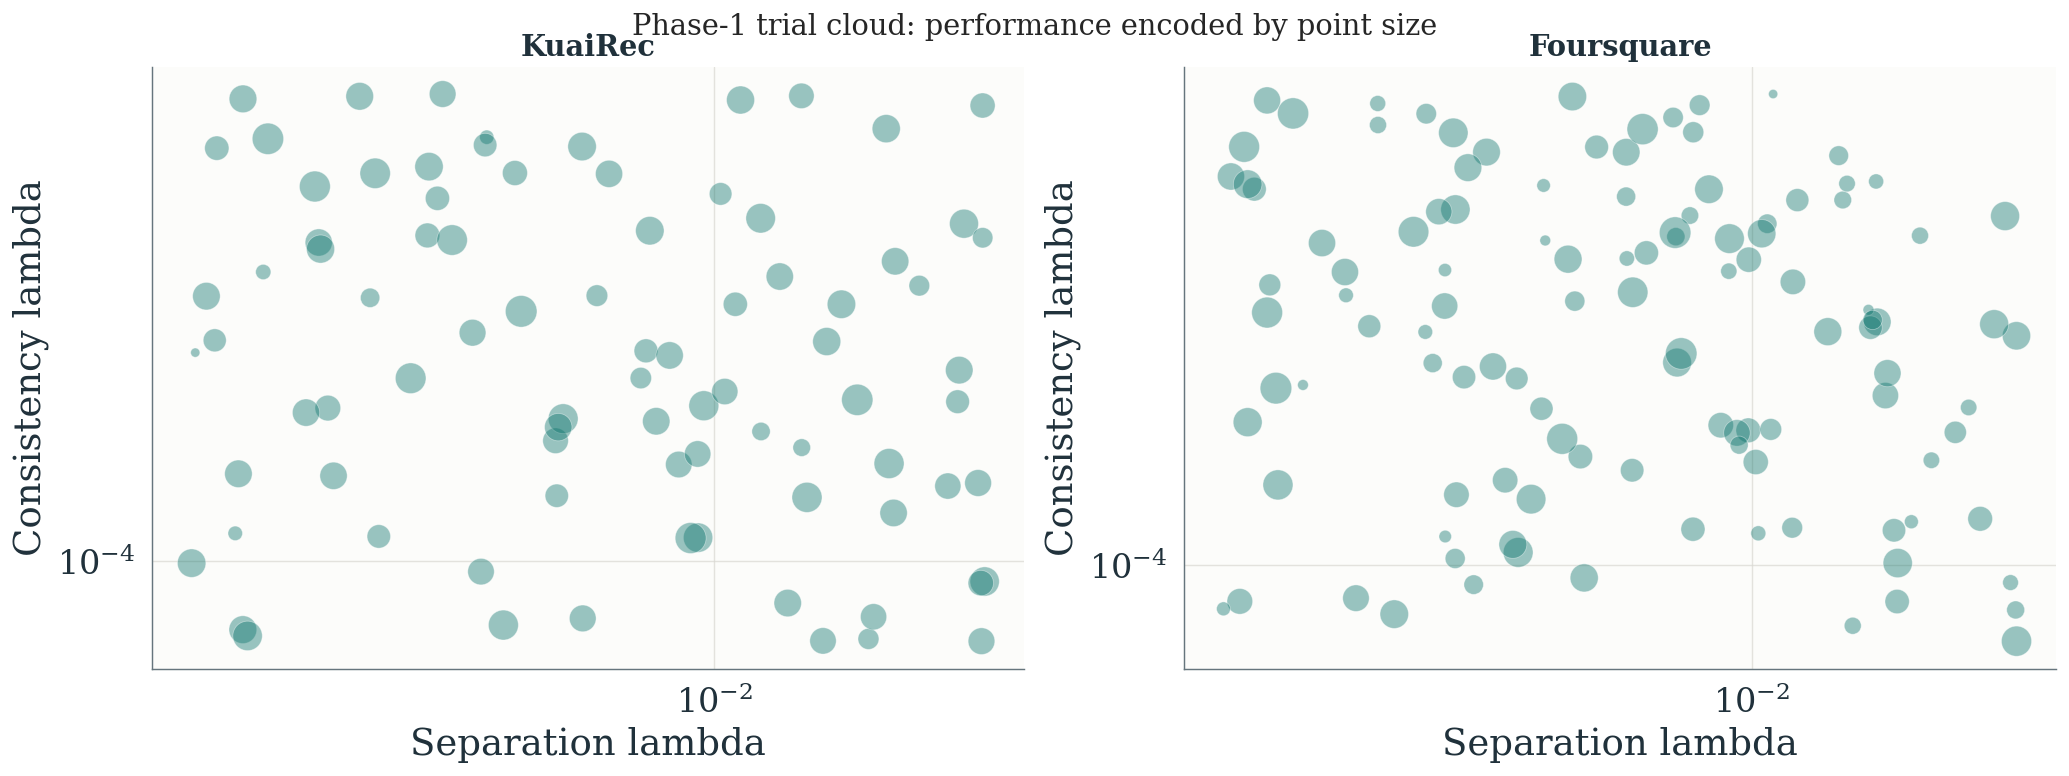

In [67]:
apply_style()
fig, axes = plt.subplots(1, len(DATASETS), figsize=(15.8, 5.7), constrained_layout=True)
if len(DATASETS) == 1:
    axes = [axes]

for ax, dataset in zip(axes, DATASETS):
    sub = phase1_plot_pool[phase1_plot_pool["dataset"] == dataset].copy()
    perf_min = sub["test_mean"].min()
    perf_span = max(sub["test_mean"].max() - perf_min, 1e-9)
    sub["perf_norm"] = (sub["test_mean"] - perf_min) / perf_span
    sizes = 26 + 280 * sub["perf_norm"]
    ax.scatter(
        sub["route_separation_lambda"].clip(lower=1e-7),
        sub["route_consistency_lambda"].clip(lower=1e-7),
        s=sizes,
        color=PALETTE["route"],
        alpha=0.42,
        edgecolor="white",
        linewidth=0.45,
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(dataset_label(dataset))
    ax.set_xlabel("Separation lambda")
    ax.set_ylabel("Consistency lambda")
    clean_axes(ax)

fig.suptitle("Phase-1 trial cloud: performance encoded by point size", y=1.02, fontsize=16)
plt.show()

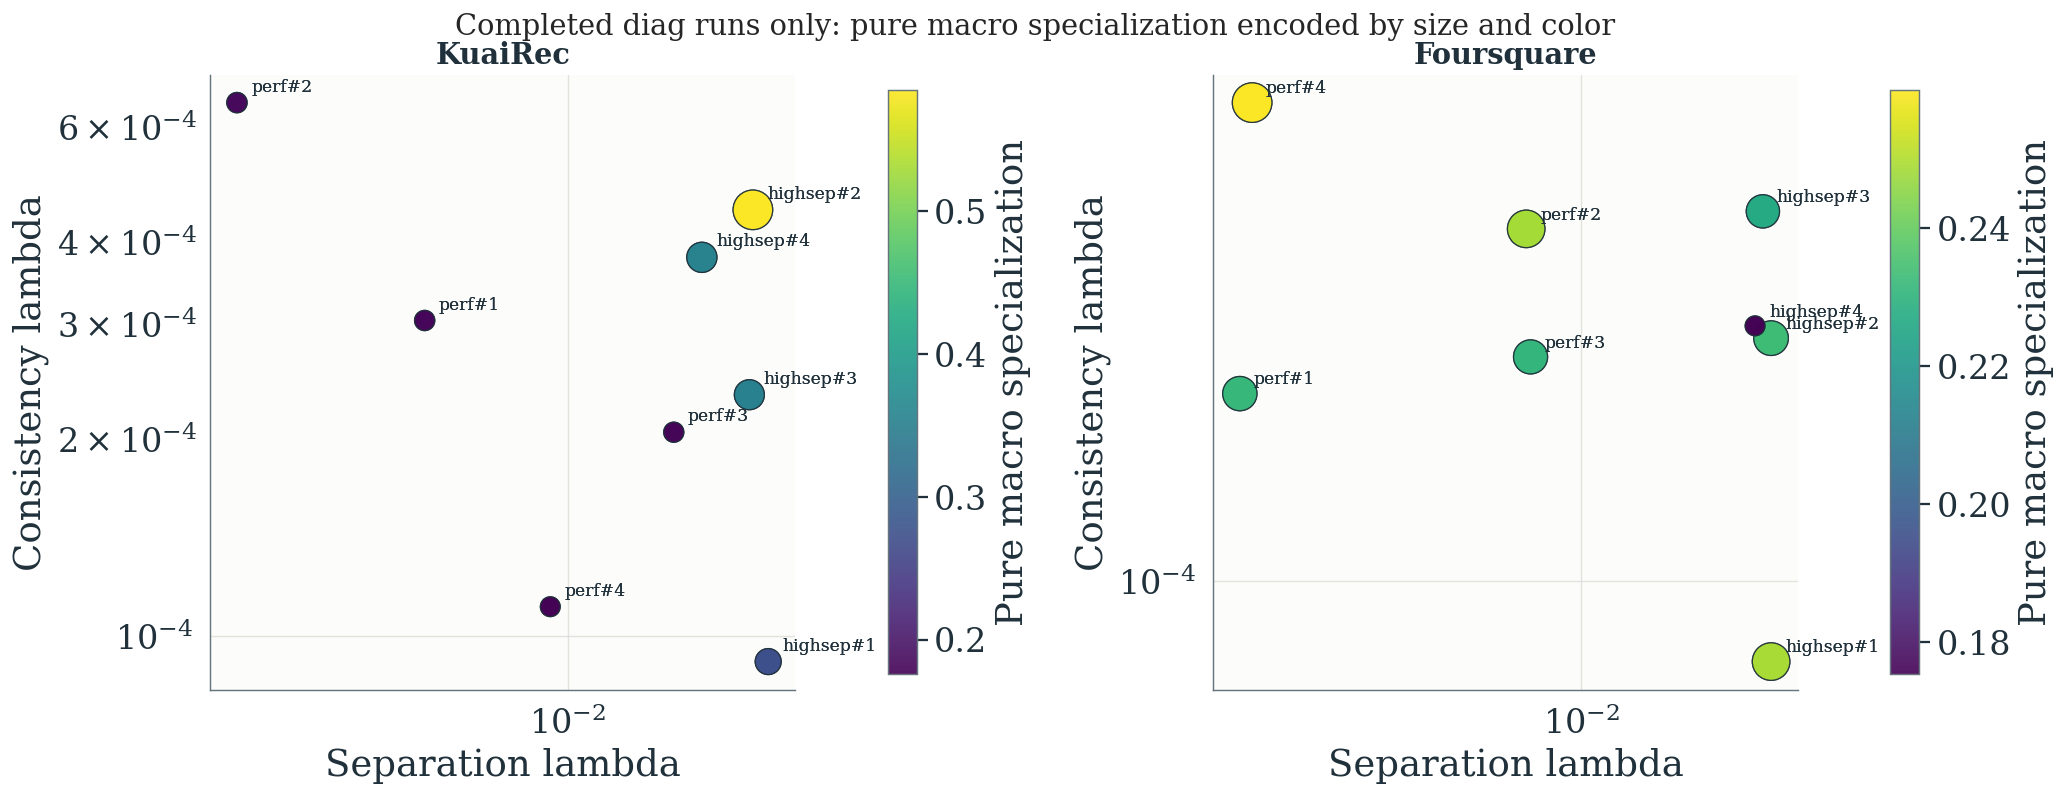

In [68]:
apply_style()
fig, axes = plt.subplots(1, len(DATASETS), figsize=(15.8, 5.8), constrained_layout=True)
if len(DATASETS) == 1:
    axes = [axes]

for ax, dataset in zip(axes, DATASETS):
    sub = diag_specialization[diag_specialization["dataset"] == dataset].copy()
    if sub.empty:
        ax.set_axis_off()
        continue
    spec_min = sub["pure_macro_specialization"].min()
    spec_span = max(sub["pure_macro_specialization"].max() - spec_min, 1e-9)
    sub["spec_norm"] = (sub["pure_macro_specialization"] - spec_min) / spec_span
    sizes = 120 + 360 * sub["spec_norm"]
    points = ax.scatter(
        sub["route_separation_lambda"].clip(lower=1e-7),
        sub["route_consistency_lambda"].clip(lower=1e-7),
        s=sizes,
        c=sub["pure_macro_specialization"],
        cmap="viridis",
        edgecolor=PALETTE["ink"],
        linewidth=0.7,
        alpha=0.9,
    )
    for row in sub.itertuples(index=False):
        ax.text(
            max(row.route_separation_lambda, 1e-7) * 1.08,
            max(row.route_consistency_lambda, 1e-7) * 1.04,
            row.run_label,
            fontsize=9.5,
            color=PALETTE["ink"],
        )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(dataset_label(dataset))
    ax.set_xlabel("Separation lambda")
    ax.set_ylabel("Consistency lambda")
    clean_axes(ax)
    fig.colorbar(points, ax=ax, pad=0.02, fraction=0.05, label="Pure macro specialization")

fig.suptitle("Completed diag runs only: pure macro specialization encoded by size and color", y=1.03, fontsize=16)
plt.show()

## 10. Pure Case Heatmaps
아래 heatmap은 completed case-eval run에서 `pure`만 사용한다. KuaiRec은 `PERF02_T25_DIAG`, Foursquare는 현재 case-eval export가 실제로 존재하는 `PERF01_T03_DIAG`를 고정한다.

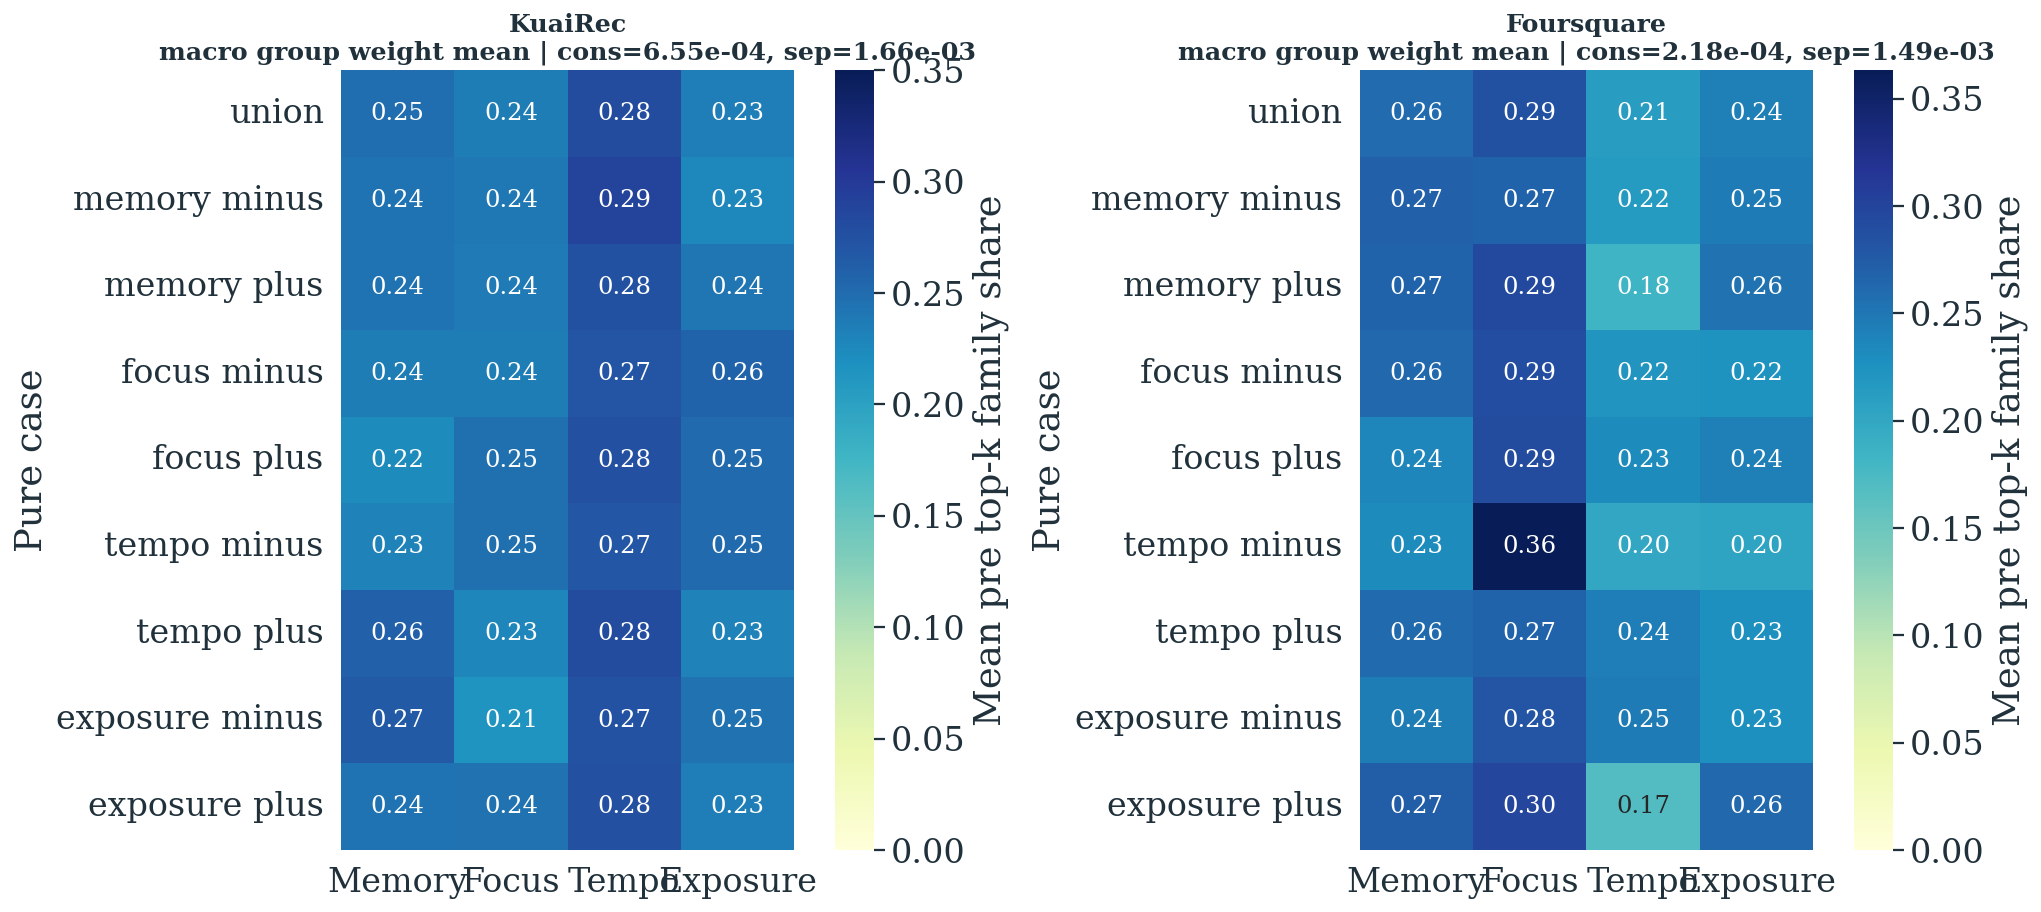

In [69]:
apply_style()
fig, axes = plt.subplots(1, len(DATASETS), figsize=(15.6, 6.9), constrained_layout=True)
if len(DATASETS) == 1:
    axes = [axes]

for ax, dataset in zip(axes, DATASETS):
    bundle = selected_case_bundles[dataset]
    pure_labels = pure_case_order(bundle["stage"])
    routing = bundle["routing"].copy()
    routing = routing[
        routing.get("tier", "").astype(str).eq("pure")
        & routing.get("stage_bucket", "").astype(str).eq(PURE_STAGE)
        & routing.get("label", "").astype(str).isin(pure_labels)
    ].copy()
    routing = prefer_eval_split(routing, preferred="test")
    routing["family_key"] = routing["routed_family"].astype(str).str.strip().str.lower()

    if routing.empty:
        ax.set_axis_off()
        ax.text(0.5, 0.5, "No pure macro routing rows", ha="center", va="center", fontsize=12)
        continue

    matrix = (
        routing.groupby(["label", "family_key"], as_index=False)["usage_share"]
        .mean()
        .pivot(index="label", columns="family_key", values="usage_share")
        .fillna(0.0)
    )
    row_order = [label for label in pure_labels if label in matrix.index]
    col_order = [family for family in FAMILY_ORDER if family in matrix.columns]
    matrix = matrix.reindex(index=row_order, columns=col_order).fillna(0.0)
    matrix.index = [
        "union" if label == "pure_union" else label.replace("pure__", "").replace("_", " ")
        for label in matrix.index
    ]
    matrix.columns = [family_title(column) for column in matrix.columns]
    meta = selected_case_runs[selected_case_runs["dataset"] == dataset_label(dataset)].iloc[0]
    sns.heatmap(
        matrix,
        cmap="YlGnBu",
        vmin=0.0,
        vmax=max(0.35, float(matrix.to_numpy().max())),
        annot=True,
        fmt=".2f",
        cbar_kws={"label": "Mean pre top-k family share"},
        ax=ax,
    )
    ax.set_title(
        f"{dataset_label(dataset)}\nmacro group weight mean | cons={meta.route_consistency_lambda:.2e}, sep={meta.route_separation_lambda:.2e}",
        fontsize=14,
    )
    ax.set_xlabel("")
    ax.set_ylabel("Pure case")

plt.show()

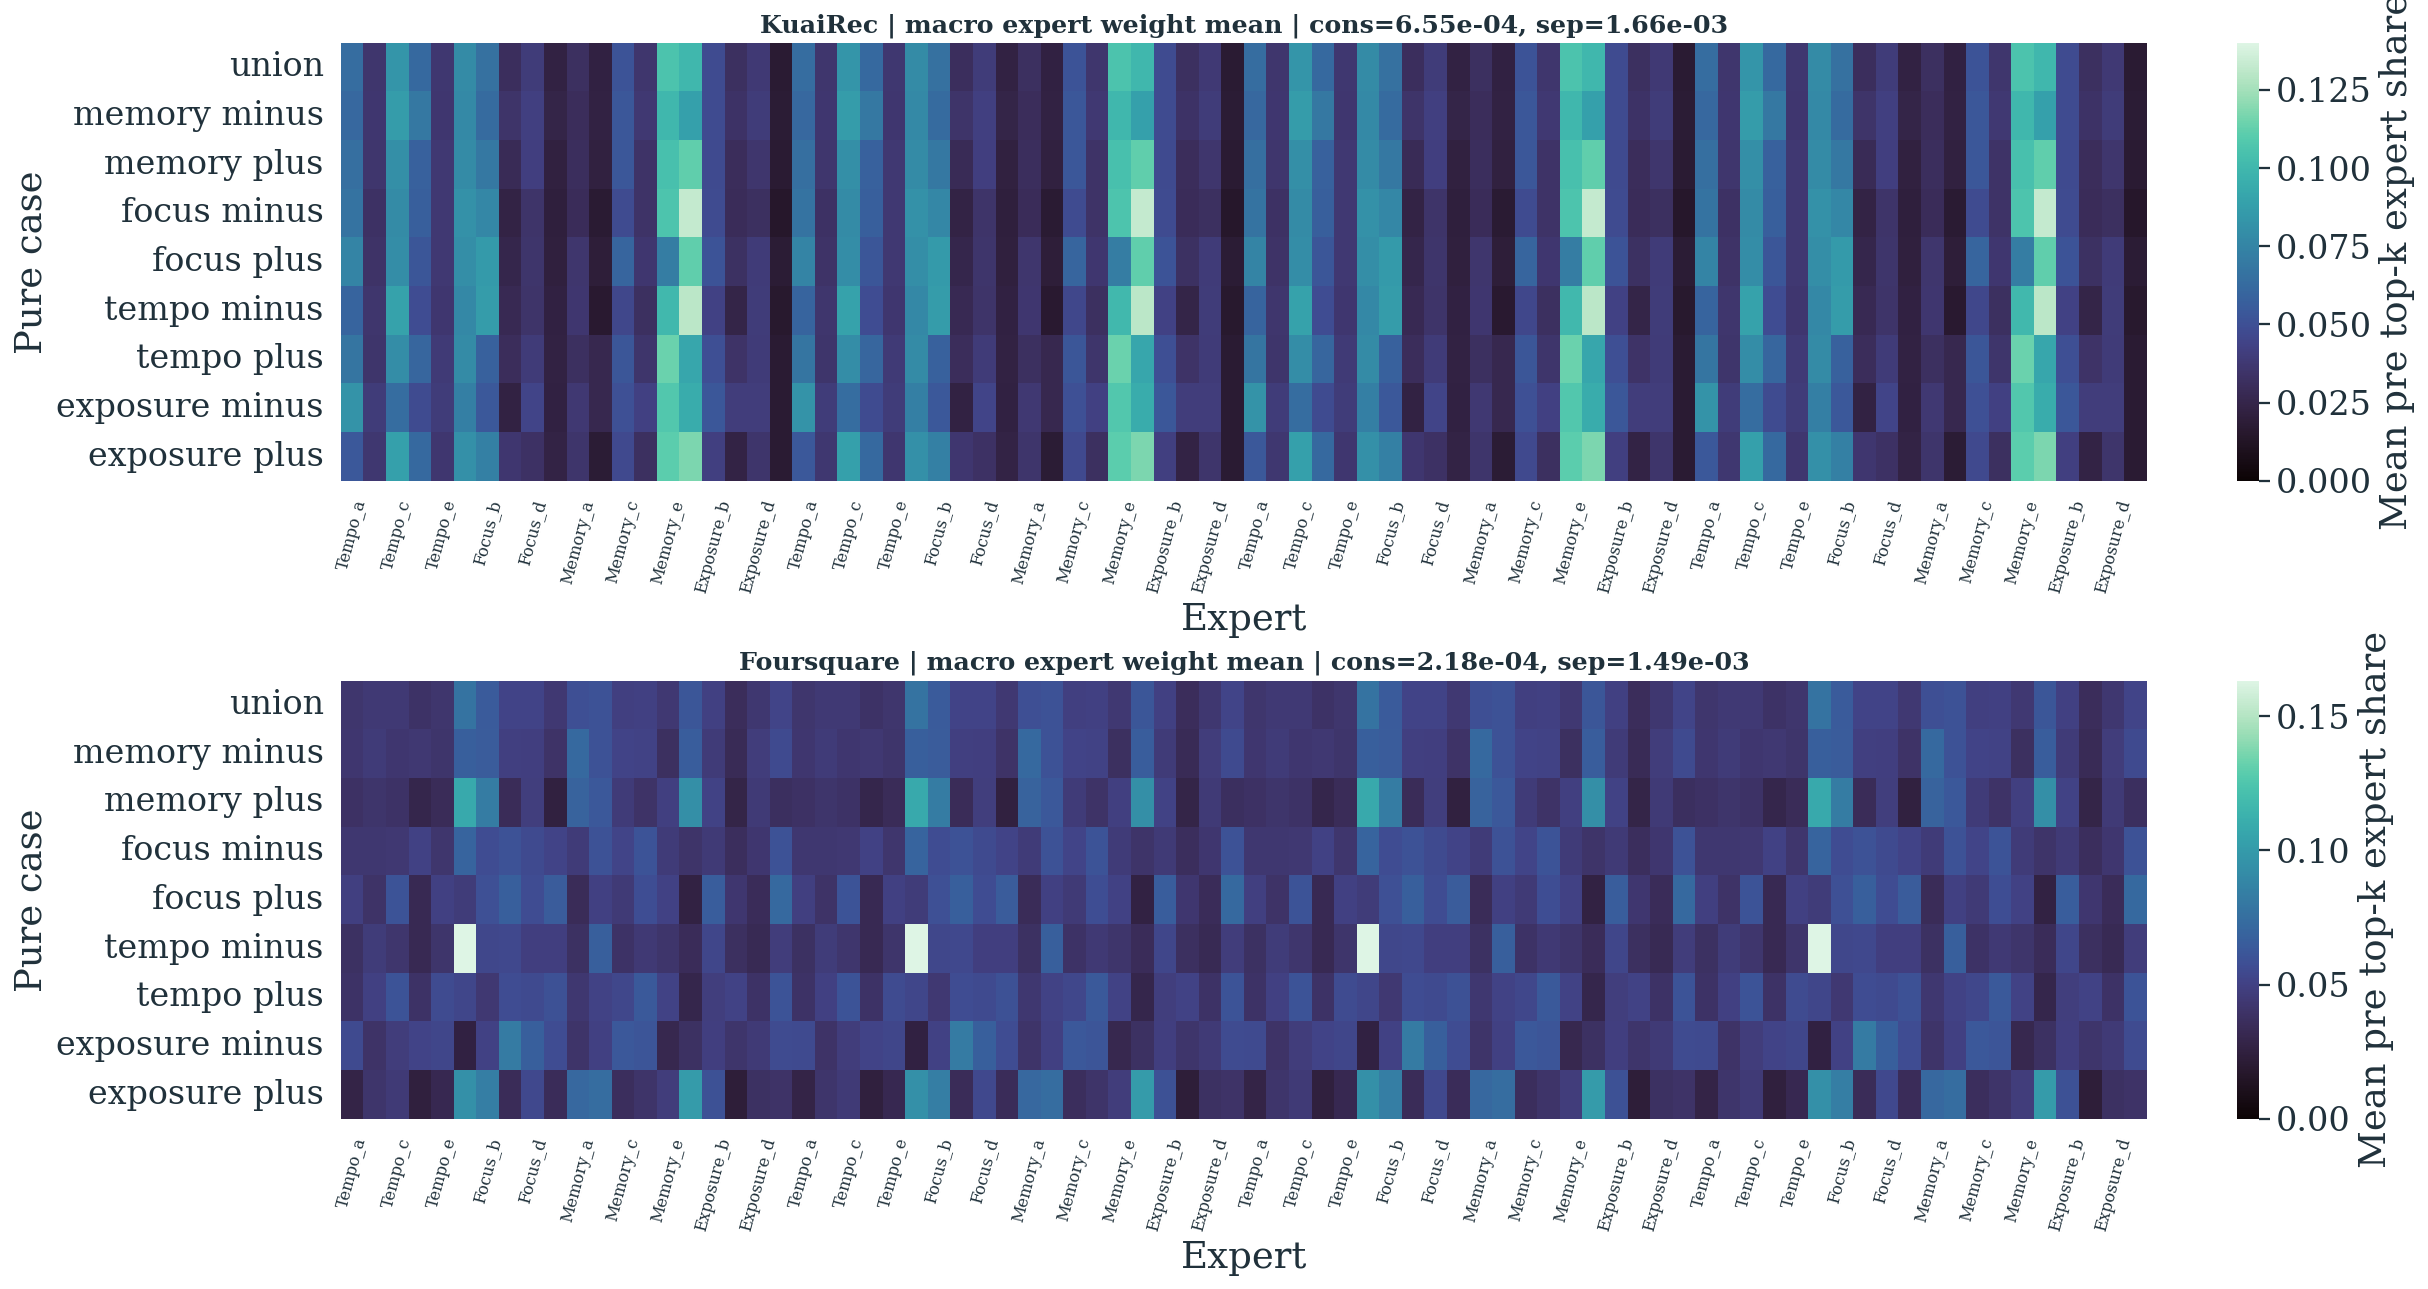

In [70]:
apply_style()
fig, axes = plt.subplots(len(DATASETS), 1, figsize=(18.6, 9.8), constrained_layout=True)
if len(DATASETS) == 1:
    axes = [axes]

for ax, dataset in zip(axes, DATASETS):
    matrix = build_pure_expert_matrix(selected_case_bundles[dataset]).copy()
    matrix.index = [
        "union" if label == "pure_union" else label.replace("pure__", "").replace("_", " ")
        for label in matrix.index
    ]
    meta = selected_case_runs[selected_case_runs["dataset"] == dataset_label(dataset)].iloc[0]
    sns.heatmap(
        matrix,
        cmap="mako",
        vmin=0.0,
        vmax=max(0.14, float(matrix.to_numpy().max())),
        cbar_kws={"label": "Mean pre top-k expert share"},
        ax=ax,
    )
    ax.set_title(
        f"{dataset_label(dataset)} | macro expert weight mean | cons={meta.route_consistency_lambda:.2e}, sep={meta.route_separation_lambda:.2e}",
        fontsize=14,
    )
    ax.set_xlabel("Expert")
    ax.set_ylabel("Pure case")
    ax.tick_params(axis="x", rotation=75, labelsize=9)

plt.show()

request 6은 현재 export된 aggregate table만으로는 raw user subset을 직접 복원할 수 없어서, `pure` 중에서 `group_top1_max_frac`가 높고 `group_n_eff`가 낮은 상위 case를 extreme proxy로 사용한다.

,dataset_label,label,selected_family,selected_polarity,group_top1_max_frac,group_n_eff,feature_group_consistency_mean_score
0,KuaiRec,pure__exposure_minus,exposure,minus,0.336,3.967,0.924
1,KuaiRec,pure__memory_minus,memory,minus,0.332,3.966,0.977
2,KuaiRec,pure__focus_plus,focus,plus,0.324,3.977,0.924
3,KuaiRec,pure__tempo_plus,tempo,plus,0.318,3.970,0.950
4,Foursquare,pure__tempo_minus,tempo,minus,0.432,3.737,0.843
5,Foursquare,pure__exposure_plus,exposure,plus,0.352,3.856,0.826
6,Foursquare,pure__exposure_minus,exposure,minus,0.344,3.975,0.868
7,Foursquare,pure__focus_plus,focus,plus,0.328,3.964,0.830


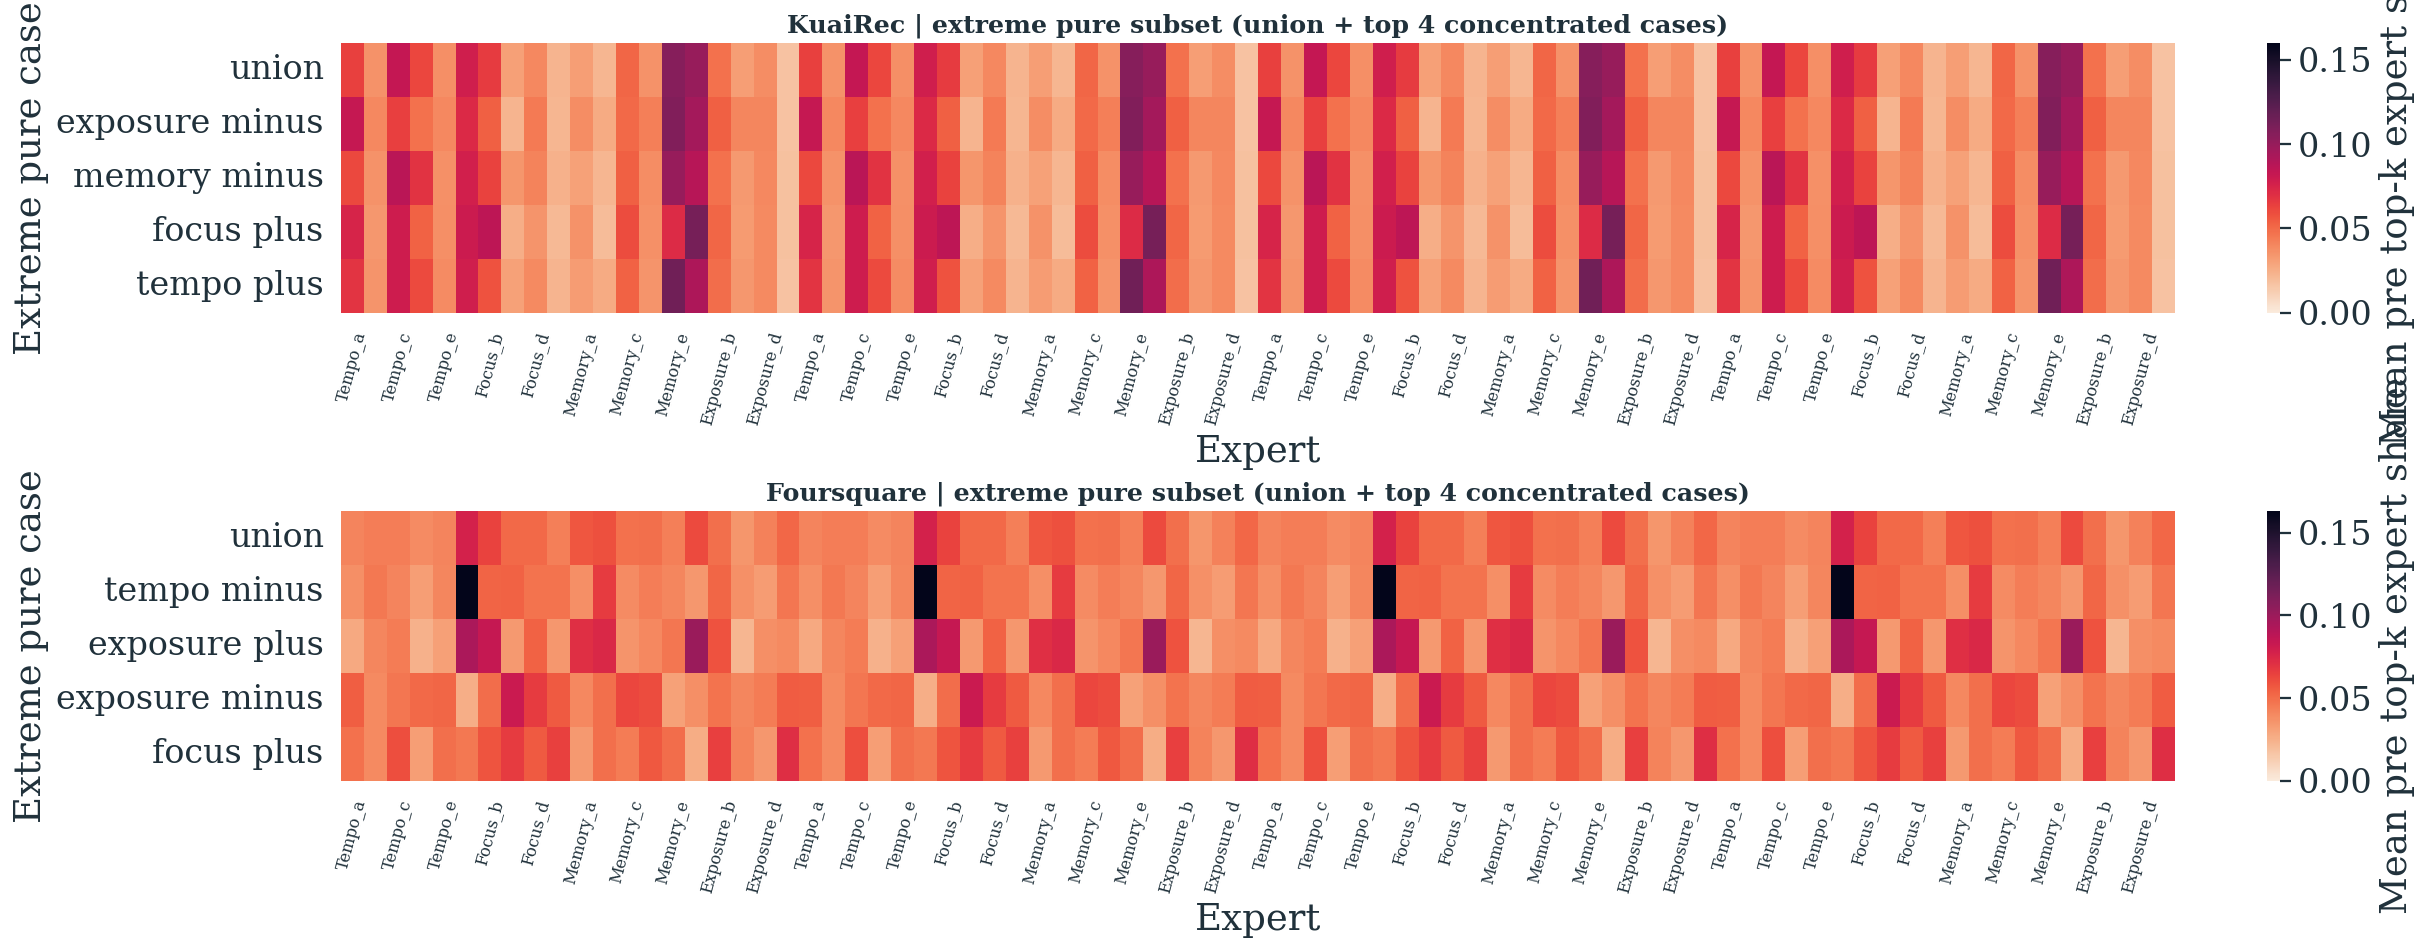

In [71]:
extreme_rows = []
for dataset in DATASETS:
    bundle = selected_case_bundles[dataset]
    stage = bundle["stage"].copy()
    stage = stage[
        stage.get("tier", "").astype(str).eq("pure")
        & stage.get("scope", "").astype(str).eq("tier_group")
        & stage.get("stage_bucket", "").astype(str).eq(PURE_STAGE)
    ].copy()
    stage = prefer_eval_split(stage, preferred="test")
    ranked = stage.sort_values(
        ["group_top1_max_frac", "feature_group_consistency_mean_score", "group_n_eff"],
        ascending=[False, False, True],
    ).copy()
    ranked["dataset_label"] = dataset_label(dataset)
    extreme_rows.append(ranked[[
        "dataset_label", "label", "selected_family", "selected_polarity",
        "group_top1_max_frac", "group_n_eff", "feature_group_consistency_mean_score",
    ]].head(4))

extreme_case_summary = pd.concat(extreme_rows, ignore_index=True)
display(extreme_case_summary.style.format({
    "group_top1_max_frac": "{:.3f}",
    "group_n_eff": "{:.3f}",
    "feature_group_consistency_mean_score": "{:.3f}",
}))

apply_style()
fig, axes = plt.subplots(len(DATASETS), 1, figsize=(18.6, 7.2), constrained_layout=True)
if len(DATASETS) == 1:
    axes = [axes]

for ax, dataset in zip(axes, DATASETS):
    labels = select_extreme_pure_labels(selected_case_bundles[dataset], top_n=4)
    matrix = build_pure_expert_matrix(selected_case_bundles[dataset], labels=labels).copy()
    matrix.index = [
        "union" if label == "pure_union" else label.replace("pure__", "").replace("_", " ")
        for label in matrix.index
    ]
    sns.heatmap(
        matrix,
        cmap="rocket_r",
        vmin=0.0,
        vmax=max(0.16, float(matrix.to_numpy().max())),
        cbar_kws={"label": "Mean pre top-k expert share"},
        ax=ax,
    )
    ax.set_title(f"{dataset_label(dataset)} | extreme pure subset (union + top 4 concentrated cases)", fontsize=14)
    ax.set_xlabel("Expert")
    ax.set_ylabel("Extreme pure case")
    ax.tick_params(axis="x", rotation=75, labelsize=9)

plt.show()